In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from multiprocessing import Pool, cpu_count
from tqdm import tqdm

import matplotlib.cm as cm
import colormaps as cmaps
import matplotlib.colors as colors
from labellines import labelLines
from matplotlib.cm import brg, ScalarMappable
from matplotlib.colors import (
    LogNorm,
    TwoSlopeNorm,
    LinearSegmentedColormap,
    Normalize,
    ListedColormap,
)
from matplotlib.lines import Line2D

import jax
import jax.numpy as jnp
from jax import random
from jax import vmap

# plt.rcParams.update(
# {"text.usetex": True, "font.family": "Helvetica", "font.size": 8}
# )

plt.rcParams.update(
    {
        "text.usetex": False,
        "font.family": "sans-serif",
        "font.sans-serif": ["Calibri"],
        "font.size": 8,
        "mathtext.fontset": "cm",
    }
)

gnuplot_barve = cm.gnuplot2_r(np.linspace(0.3, 1, 10))
gnuplot_custom = LinearSegmentedColormap.from_list("gnuplot_custom", gnuplot_barve)

brg_barve = cmaps.guppy(np.linspace(0, 1, 10))
bgr_custom = LinearSegmentedColormap.from_list("bgr_custom", brg_barve)

YlGn_barve = cm.YlGn(np.linspace(0, 0.8, 10))
ylgn_custom = LinearSegmentedColormap.from_list("ylgn_custom", YlGn_barve)

markers = ["o", "D", "^", "x", "v", "<", ">", "p", "*", "X"]

set1_list = [
    "#e41a1c",
    "#377eb8",
    "#4daf4a",
    "#984ea3",
    "#ff7f00",
    "#f781bf",
    "#999999",
    "#a65628",
]
bold_list = [
    "#7f3c8d",
    "#11a579",
    "#3969ac",
    "#e73f74",
    "#f2b701",
    "#80ba5a",
    "#e68310",
    "#008695",
    "#cf1c90",
    "#f97b72",
    "#a5aa99",
]

OUT = "/home/kzeleznikar/IJS-F1/Koda/toymodels/plots/"

W = 5.0


def newfig(h=0.6):
    fig, ax = plt.subplots(figsize=(W, h * W))
    ax.tick_params(which="both", direction="in")
    return fig, ax

In [14]:
def gap(t, d0, lam=0.3, wd=1.0, a=0.5):
    n = 5000
    dx = wd / n
    x = (np.arange(n) + 0.5) * dx
    d = max(d0, 1e-8)

    for _ in range(50000):
        e = np.sqrt(x**2 + d**2)

        if t == 0.0:
            q = np.ones_like(e)
        else:
            q = np.tanh(e / (2.0 * t))

        dr = lam * d * dx * np.sum(q / e)
        dn = (1.0 - a) * d + a * dr

        if dn < 1e-9:
            return 0.0

        if abs(dn - d) < 1e-10:
            return dn

        d = dn

    raise RuntimeError("Gap iteration did not converge")

In [68]:
lam = 0.3
wd = 1.3

ts = np.linspace(0.0, 0.06, 80)
ds = np.empty_like(ts)

d = 2.0 * wd * np.exp(-1.0 / lam)

for i, t in enumerate(ts):
    d = gap(t, d, lam, wd)
    ds[i] = d

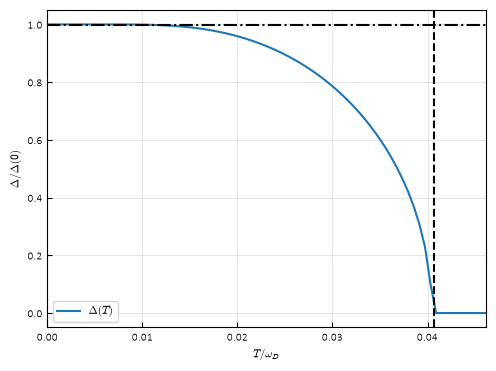

In [70]:
h = 0.7
fig, ax = newfig(0.75)

ax.plot(ts / wd, ds / ds[0], label=r"$\Delta(T)$")
ax.set_xlim(ts[0] / wd, ts[-1] / wd)
ax.set_xlabel(r"$T/\omega_D$")
ax.set_ylabel(r"$\Delta/\Delta(0)$")
ax.grid(alpha=0.3)
ax.legend()
ax.axvline(x=1.14 * np.exp(-1.0 / lam), color="k", ls="--")
ax.axhline(y=2 * wd * np.exp(-1.0 / lam) / ds[0], color="k", ls="-.")

plt.tight_layout()
plt.savefig(OUT + "BCS_gap_test.pdf")
plt.show()

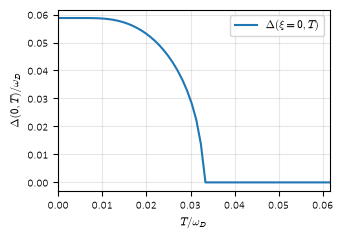

In [76]:
def gap(t, d0, x, rho, v, a=0.4):
    dx = x[1] - x[0]
    d = np.array(d0, dtype=float)

    if np.max(np.abs(d)) == 0.0:
        d[:] = 1e-6

    for _ in range(50000):
        e = np.sqrt(x**2 + np.abs(d) ** 2)

        if t == 0.0:
            q = np.ones_like(e)
        else:
            q = np.tanh(e / (2.0 * t))

        y = dx * rho * d * q / (2.0 * e)
        dr = v @ y
        dn = (1.0 - a) * d + a * dr

        if np.max(np.abs(dn)) < 1e-9:
            return np.zeros_like(dn)

        if np.max(np.abs(dn - d)) < 1e-10:
            return dn

        d = dn

    raise RuntimeError("Gap iteration did not converge")


wd = 1.3
n = 800
dx = 2.0 * wd / n
x = -wd + (np.arange(n) + 0.5) * dx

rho = 1.0 + 2 * x / wd

v0 = 0.4
s = 0.5
z = x[:, None] - x[None, :]
v = v0 * np.exp(-0.5 * (z / s) ** 2)

ts = np.linspace(0.0, 0.08, 60)
ds = np.zeros((len(ts), n))
dfs = np.zeros_like(ts)

d = 0.05 * np.ones(n)

for i, t in enumerate(ts):
    d = gap(t, d, x, rho, v)
    ds[i] = d
    dfs[i] = np.interp(0.0, x, d)


h = 0.7
fig, ax = plt.subplots(figsize=(3.47412, h * 3.47412))

ax.plot(ts / wd, dfs / wd, label=r"$\Delta(\xi=0,T)$")
ax.set_xlim(ts[0] / wd, ts[-1] / wd)
ax.set_xlabel(r"$T/\omega_D$")
ax.set_ylabel(r"$\Delta(0,T)/\omega_D$")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

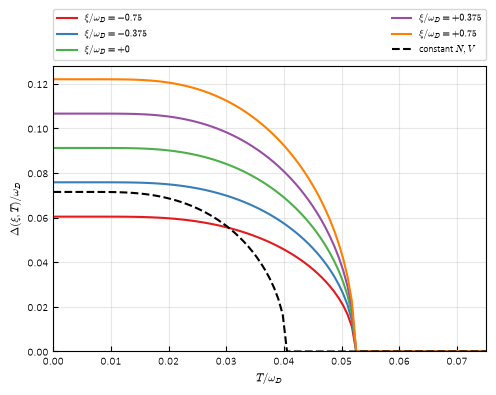

In [84]:

def sol(t, x, r, f, g):
    dx = x[1] - x[0]

    def q(d):
        e = np.sqrt(x**2 + (d * f)**2)
        th = np.ones_like(e) if t == 0 else np.tanh(e / (2 * t))
        return g * dx * np.sum(r * f**2 * th / (2 * e)) - 1

    if q(0.0) <= 0:
        return 0.0

    lo, hi = 0.0, 0.1
    while q(hi) > 0:
        hi *= 2

    for _ in range(80):
        md = 0.5 * (lo + hi)

        if q(md) > 0:
            lo = md
        else:
            hi = md

    return 0.5 * (lo + hi)


wd = 1.0
g = 0.30
x = np.linspace(-wd, wd, 1000)

rho = 1.0 + 0.35 * x / wd
f = 1.0 + 0.45 * x / wd

ts = np.linspace(0.0, 0.075, 101)

da = np.array([sol(t, x, rho, f, g) for t in ts])
db = np.array([
    sol(t, x, np.ones_like(x), np.ones_like(x), g)
    for t in ts
])

xs = np.array([-0.75, -0.375, 0.0, 0.375, 0.75]) * wd
fs = 1.0 + 0.45 * xs / wd

h = 0.85
fig, ax = newfig(0.8)

for i, (z, q) in enumerate(zip(xs, fs)):
    ax.plot(
        ts / wd,
        q * da / wd,
        color=set1_list[i],
        label=rf'$\xi/\omega_D={z / wd:+.3g}$',
    )

ax.plot(
    ts / wd,
    db / wd,
    color="black",
    ls="--",
    label=r'constant $N,V$',
)

ax.set_xlim(ts[0] / wd, ts[-1] / wd)
ax.set_ylim(bottom=0)
ax.set_xlabel(r'$T/\omega_D$')
ax.set_ylabel(r'$\Delta(\xi,T)/\omega_D$')
ax.grid(alpha=0.3)
ax.legend(
    bbox_to_anchor=(0, 1.02, 1, 0.2),
    loc="lower left",
    mode="expand",
    borderaxespad=0,
    ncol=2,
    fontsize=7,
)

plt.tight_layout()
plt.show()

In [96]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import brentq
from scipy.special import expit


v0 = 0.5
wd = 1.0
g0 = 1.0 / wd
rr = 0.7
nf = 1.0

nx = 400
dx = wd / nx
x = (np.arange(nx) + 0.5) * dx


def fd(e, mu, t):
    te = max(t, 1e-5)
    return expit((mu - e) / te)


def solve(t, gg, y0=None, ad=0.8, an=0.35, Nmax=5000):
    if y0 is None:
        d = 0.08
        na = 0.5
        nb = 0.5
        mu = 0.0
    else:
        d, na, nb, mu = y0
        d = max(d, 1e-7)

    for _ in range(Nmax):
        ea = 0.5 * gg + x + v0 * nb
        eb = -0.5 * gg - rr * x + v0 * na

        et = 0.5 * (ea + eb)
        xi = 0.5 * (ea - eb)
        ek = np.sqrt(xi**2 + d**2)

        ep = et + ek
        em = et - ek

        lo = min(ep.min(), em.min()) - 3.0 * wd
        hi = max(ep.max(), em.max()) + 3.0 * wd

        def num(m):
            fp = fd(ep, m, t)
            fm = fd(em, m, t)
            return g0 * dx * np.sum(fp + fm) - nf

        mur = brentq(num, lo, hi)

        fp = fd(ep, mur, t)
        fm = fd(em, mur, t)

        u2 = 0.5 * (1.0 + xi / ek)
        v2 = 1.0 - u2

        nar = g0 * dx * np.sum(u2 * fp + v2 * fm)
        nbr = g0 * dx * np.sum(v2 * fp + u2 * fm)

        dr = v0 * g0 * dx * np.sum(
            d * (fm - fp) / (2.0 * ek)
        )

        dn = (1.0 - ad) * d + ad * dr
        nan = (1.0 - an) * na + an * nar
        nbn = (1.0 - an) * nb + an * nbr
        mun = (1.0 - an) * mu + an * mur

        er = max(
            abs(dn - d),
            abs(nan - na),
            abs(nbn - nb),
            abs(mun - mu),
        )

        d = dn
        na = nan
        nb = nbn
        mu = mun

        if er < 1e-8:
            if abs(d) < 1e-6:
                d = 0.0

            return np.array([d, na, nb, mu])

    raise RuntimeError("Iteration did not converge")

In [99]:
t = 0.02
gg = -0.5

d, na, nb, mu = solve(t, gg)
gh = gg + v0 * (nb - na)

print("Delta =", d)
print("n_a =", na)
print("n_b =", nb)
print("mu =", mu)
print("G_H =", gh)

print(na + nb)

Delta = 0.08035180007699996
n_a = 0.07024039418664127
n_b = 0.9297596058133633
mu = 0.25941513238747205
G_H = -0.07024039418663902
1.0000000000000044


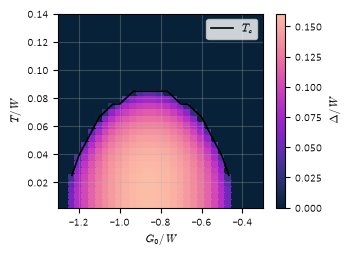

In [ ]:
ng = 31
nt = 31

gs = np.linspace(-1.3, -0.3, ng)
ts = np.linspace(0.002, 0.14, nt)

dm = np.zeros((nt, ng))
am = np.zeros((nt, ng))
bm = np.zeros((nt, ng))

for j, gg in enumerate(gs):
    y = None

    for i, t in enumerate(ts):
        y = solve(t, gg, y, Nmax=50000)

        dm[i, j] = y[0]
        am[i, j] = y[1]
        bm[i, j] = y[2]


tc = np.full(ng, np.nan)

for j in range(ng):
    ii = np.where(dm[:, j] > 1e-5)[0]

    if len(ii) > 0:
        tc[j] = ts[ii[-1]]



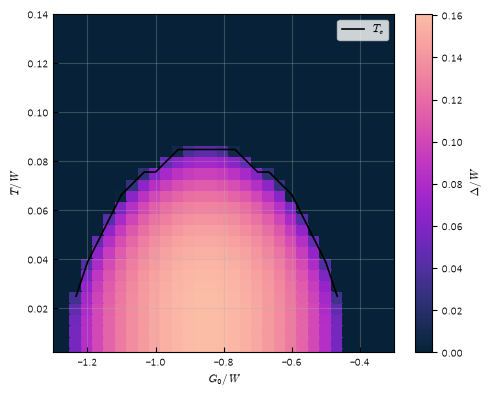

In [101]:

fig, ax = newfig(0.8)
im = ax.pcolormesh(
    gs / wd,
    ts / wd,
    dm / wd,
    shading="auto",
    cmap=cmaps.bubblegum,
)
im.set_edgecolor("face")

ax.plot(
    gs / wd,
    tc / wd,
    color="black",
    lw=1.2,
    label=r'$T_c$',
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(
    r'$\Delta/\mathit{W}$',
    rotation=90,
    labelpad=5,
)

ax.set_xlim(gs[0] / wd, gs[-1] / wd)
ax.set_ylim(ts[0] / wd, ts[-1] / wd)
ax.set_xlabel(r'$G_0/\mathit{W}$')
ax.set_ylabel(r'$T/\mathit{W}$')
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()